<a href="https://colab.research.google.com/github/H1af2e3m4a5n6n/data-science-estudos/blob/main/Detector_Fake_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 Detector de Fake News

Este notebook treina um modelo de Machine Learning para classificar notícias como **Falsa** ou **Verdadeira**, e no final permite colar qualquer notícia para receber uma classificação com **percentual de confiança**.

**Dataset:** ISOT Fake and Real News Dataset, já unificado em um único arquivo `noticias_unificadas.csv` (coluna `label`: 0 = Falsa, 1 = Verdadeira).

⚠️ **Nota sobre o dataset:** as notícias verdadeiras desse dataset vêm quase todas de despachos da agência Reuters e começam com um padrão fixo tipo `CIDADE (Reuters) -`. Se isso não for removido, o modelo aprende a reconhecer a "assinatura" da agência em vez de aprender a diferenciar linguagem de fake news de verdade — isso é chamado de **vazamento de dados (data leakage)** e infla a acurácia de forma artificial. Este notebook remove esse padrão antes de treinar.

## 1. Instalação e imports

In [1]:
!pip install -q ipywidgets scikit-learn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import ipywidgets as widgets
from IPython.display import display, clear_output

sns.set_style("whitegrid")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 46.6 MB/s eta 0:00:00


## 2. Upload do arquivo

Faça upload de `noticias_unificadas.csv` (já contém falsas e verdadeiras juntas, com a coluna `label`).

In [3]:
from google.colab import files

print("Selecione noticias_unificadas.csv")
uploaded = files.upload()

Selecione noticias_unificadas.csv


Saving noticias_unificadas.csv to noticias_unificadas.csv


In [4]:
df = pd.read_csv("noticias_unificadas.csv")

print("Total de notícias:", df.shape[0])
print(df["label"].value_counts().rename({0: "Falsa", 1: "Verdadeira"}))

Total de notícias: 44898
label
Falsa         23481
Verdadeira    21417
Name: count, dtype: int64


## 3. Análise exploratória rápida

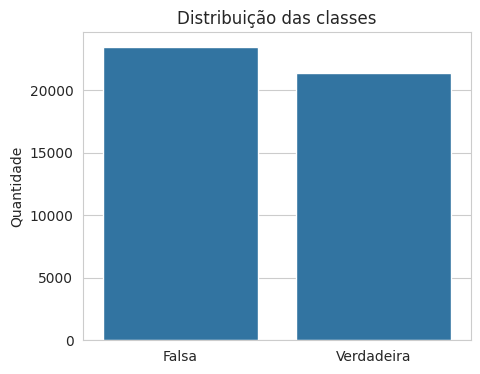

In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["label"].map({0: "Falsa", 1: "Verdadeira"}))
plt.title("Distribuição das classes")
plt.xlabel("")
plt.ylabel("Quantidade")
plt.show()

## 4. Pré-processamento (removendo o vazamento)

Aqui:
- Combinamos `title` + `text` em um único campo.
- Removemos o prefixo `CIDADE (Reuters) -` que só aparece nas notícias verdadeiras.
- Removemos qualquer menção residual a `(Reuters)`.
- Removemos URLs e caracteres especiais em excesso.
- Descartamos `subject` e `date`, que também vazam a resposta (a coluna `subject` sozinha já separa as classes quase perfeitamente).

In [6]:
def clean_text(text):
    text = str(text)
    # Remove o padrão "CIDADE (Reuters) -" no início do texto
    text = re.sub(r'^.{0,60}?\(Reuters\)\s*-\s*', '', text)
    # Remove qualquer menção remanescente a (Reuters)
    text = re.sub(r'\(Reuters\)', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove caracteres não alfabéticos (mantém pontuação básica)
    text = re.sub(r'[^A-Za-zÀ-ÿ\s.,!?\'\"]', ' ', text)
    # Normaliza espaços
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df["full_text"] = (df["title"].astype(str) + " " + df["text"].astype(str))
df["full_text_clean"] = df["full_text"].apply(clean_text)

df[["full_text", "full_text_clean", "label"]].head(3)

,full_text,full_text_clean,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls out th circuit court committed...,0
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon from national securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u.s. to lift jones act shi...,1


## 5. Separação treino/teste

In [7]:
X = df["full_text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape[0], "| Teste:", X_test.shape[0])

Treino: 35918 | Teste: 8980


## 6. Vetorização (TF-IDF)

In [8]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Shape treino:", X_train_tfidf.shape)

Shape treino: (35918, 5000)


## 7. Treinamento do modelo

Usamos **Regressão Logística**: além de ter ótimo desempenho em classificação de texto com TF-IDF, ela fornece diretamente uma probabilidade (`predict_proba`), que vamos usar como percentual de confiança.

In [9]:
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

## 8. Avaliação do modelo

Acurácia no conjunto de teste: 98.32%

              precision    recall  f1-score   support

       Falsa       0.99      0.98      0.98      4696
  Verdadeira       0.98      0.99      0.98      4284

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



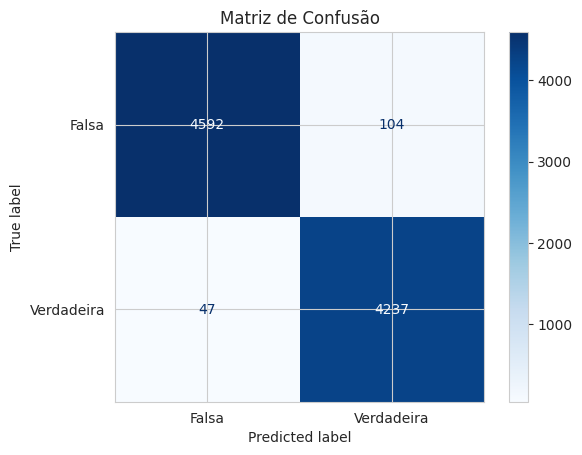

In [10]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia no conjunto de teste: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=["Falsa", "Verdadeira"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Falsa", "Verdadeira"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

## 9. Classificar uma notícia inserida pelo usuário

Cole o texto de qualquer notícia no campo abaixo e clique em **Analisar**. O modelo retorna a classificação (Falsa/Verdadeira) e o percentual de confiança.

In [13]:
texto_input = widgets.Textarea(
    value='',
    placeholder='Cole aqui o texto da notícia que deseja analisar...',
    layout=widgets.Layout(width='100%', height='180px')
)

botao_analisar = widgets.Button(
    description='Analisar notícia',
    button_style='primary',
    icon='search'
)

saida = widgets.Output()

def analisar_noticia(b):
    with saida:
        clear_output()
        texto_bruto = texto_input.value.strip()
        if len(texto_bruto) < 20:
            print("⚠️ Cole um texto de notícia com pelo menos algumas frases para uma análise confiável.")
            return

        texto_limpo = clean_text(texto_bruto)
        vetor = vectorizer.transform([texto_limpo])

        pred = model.predict(vetor)[0]
        proba = model.predict_proba(vetor)[0]
        confianca = proba[pred] * 100

        rotulo = "✅ VERDADEIRA" if pred == 1 else "🚨 FALSA"

        print(f"Classificação: {rotulo}")
        print(f"Confiança do modelo: {confianca:.2f}%")
        print(f"\n(Prob. Falsa: {proba[0]*100:.2f}% | Prob. Verdadeira: {proba[1]*100:.2f}%)")

botao_analisar.on_click(analisar_noticia)

display(texto_input, botao_analisar, saida)

Textarea(value='', layout=Layout(height='180px', width='100%'), placeholder='Cole aqui o texto da notícia que …

Button(button_style='primary', description='Analisar notícia', icon='search', style=ButtonStyle())

Output()

---
### ⚠️ Limitações a ter em mente

- O modelo foi treinado majoritariamente com notícias políticas em **inglês** dos EUA (2016–2017). Para notícias em português ou de outros temas/épocas, a confiança tende a cair.
- "Confiança" aqui é a probabilidade que o próprio modelo atribui à sua previsão — não é uma verificação factual independente da notícia.
- É um bom projeto de portfólio para demonstrar NLP + classificação de texto, mas não deve ser tratado como um verificador de fatos de verdade.